## 5. SGDClassifier

### 5.1 Packages importeren

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report,
    confusion_matrix, ConfusionMatrixDisplay)
import numpy as np

from preprocessing import(
    spacy_preprocessor,
    spacy_tokenizer,
)

### 5.2 Data inladen 

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# training set
X_train = train['Omschrijving']
y_train = train['Product']

# test set
X_test = test['Omschrijving']
y_test = test['Product']

### 5.3 TF-IDF en SGDClassifier Pipeline

In [3]:
tfidf = TfidfVectorizer(
    preprocessor=spacy_preprocessor,
    tokenizer=spacy_tokenizer,
    analyzer="word",
    token_pattern=None,
    ngram_range=(1, 2),
    sublinear_tf=True,
    norm="l2"
)

In [ ]:
model = SGDClassifier(
    max_iter=5000,
    n_jobs=-1,
    warm_start=True, # hergebruikt vorige oplossing bij opnieuw trainen 
    random_state=42,
    average=True # gebruikt gemiddelde gewichten voor stabielere resultaten 
)

sgd_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", model)])

### 5.4 Hyperparameter Tuning

#### 5.4.1 RandomizedSearchCV

In [ ]:
sgd_params = {
    # TF-IDF Parameters
    "tfidf__max_features": [20000, 30000, 50000, None],
    "tfidf__min_df": [1, 2, 3, 5],
    "tfidf__max_df": [0.75, 0.85, 0.95],
    "tfidf__ngram_range": [(1,1), (1,2), (1,3)],

    # Model Parameters
    "model__loss": ["hinge", "log_loss", "modified_huber"], # type loss functie 
    "model__alpha": stats.loguniform(1e-8, 1e-2), # voorkomt overfitting door extreme woordgewichten af te remmen
    "model__penalty": ["l2"], # type regularisatie 
    "model__class_weight": ["balanced", None], # wel of geen class balancing 
}

In [6]:
sgd_random = RandomizedSearchCV(
    estimator=sgd_pipeline,
    param_distributions=sgd_params,
    n_iter=50,
    scoring="precision_macro",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

sgd_random.fit(X_train, y_train)
best_random = sgd_random.best_params_

print("Beste parameters Random Search:", best_random)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Beste parameters Random Search: {'model__alpha': np.float64(0.00023404431241892624), 'model__class_weight': None, 'model__loss': 'hinge', 'model__penalty': 'l2', 'tfidf__max_df': 0.85, 'tfidf__max_features': 30000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 3)}


#### 5.4.3 GridSearchCV

In [ ]:
# GridSearch om de beste instellingen uit Random Search verder af te stellen 
grid_params = {
"model__alpha": [
    best_random["model__alpha"] * 0.1,
    best_random["model__alpha"] * 0.5,
    best_random["model__alpha"],
    best_random["model__alpha"] * 2,
    best_random["model__alpha"] * 5
]
}

sgd_grid = GridSearchCV(
    estimator=sgd_pipeline,
    param_grid=grid_params,
    scoring="precision_macro",
    cv=3,
    verbose=1,
    n_jobs=-1
)

sgd_grid.fit(X_train, y_train)
sgd_best = sgd_grid.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


### 5.5 Evaluatie Modelprestaties

### 5.5.1 Voorspellingen

In [8]:
y_pred = sgd_best.predict(X_test)

### 5.5.2 Classification Report

In [9]:
print("\nClassification Report SGD Classifier:\n")
print(classification_report(y_test, y_pred))


Classification Report SGD Classifier:

                    precision    recall  f1-score   support

      Bankrekening       0.89      0.85      0.87       446
Consumentenkrediet       0.79      0.55      0.65       284
        Creditcard       0.83      0.84      0.84       564
         Hypotheek       0.90      0.96      0.93       994
           Incasso       0.84      0.88      0.86      1223
Kredietregistratie       0.85      0.82      0.84       934

          accuracy                           0.86      4445
         macro avg       0.85      0.82      0.83      4445
      weighted avg       0.85      0.86      0.85      4445



### 5.5.3 Confusion Matrix

[[ 379    2   28   15   14    8]
 [   7  157   18   30   49   23]
 [  17    7  476    7   33   24]
 [  12    3    4  950   11   14]
 [   9   13   23   37 1074   67]
 [   2   18   24   20  103  767]]


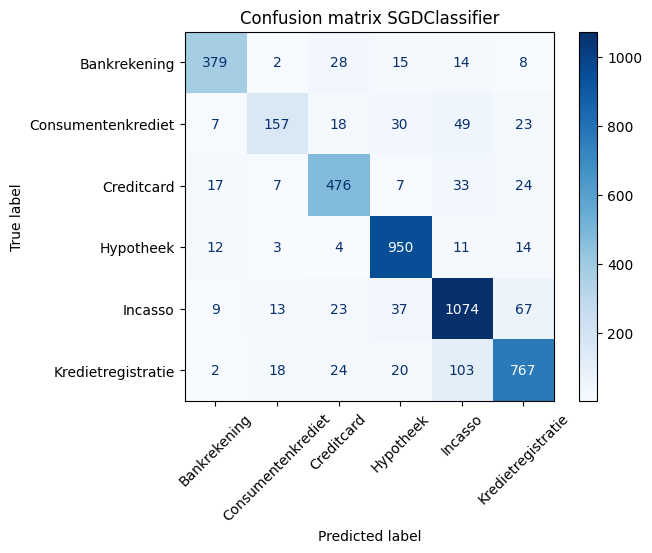

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix SGDClassifier')
plt.savefig("afbeeldingen/confusion_matrix_SGDClassifier.png", dpi=300, bbox_inches='tight') 
plt.show()

### 5.5.4 Conclusie modelprestatie 
De SGDClassifier haalt een weighted precision van 0,85. Alleen Hypotheek haalt de eis van 90% precision. De overige productsectoren blijven hier net onder, met Consumentenkrediet als laagst scorende klasse.

Ten opzichte van Logistic Regression en Naive Bayes presteert dit model iets beter, maar ook hier wordt de eis van 90% precision voor alle subklassen niet gehaald.